<a href="https://colab.research.google.com/github/oridoll/Mini_projets/blob/test_vit_cnn/vit_vs_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VIT vs CNN

The objective of this project is to compare the performances of two differents architectures for the task of image classification: Vision Transformers (ViT) and Convolutional Neural Networks (CNN). A Convolutionnal Neural Networtk is a specialized neural network designed to classify and to process images by using a local information from adjacent pixels. Its firsts layers are a combination of Convolution and Pooling layers and the last layers are a fully-connected or dense layer. A Vision Transformer uses the auto-attention mechanism to consider the relationship between all the patches of the images. 
Acccording to this paper [An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale](https://doi.org/10.48550/arXiv.2010.11929) : CNN are better over small datasets thant ViT. This what we study in this notebook.

 It is better on small datasets because there is less global parameters to learn
 It needs a large quantity of data to learn these relations without the advantage of local induction.

### Comparison of the architecture of a CNN and a ViT

reprendre le cours et expliquer (c'est la question 2) "Make sure to explain the ViT architecture in detail." JE SAIS PAS SI LA LICENSE DE L'IMAGE ESST VALIDE https://github.com/google-research/vision_transformer

![ViT](vit.png "ViT")
![CNN](cnn_architecture.png "CNN")


### Choice of the two datasets

We chose to use the dataset CIFAR10 and STL10. We explain why above.

In [59]:
#%load_ext autoreload
#%autoreload 2

import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)



cuda


For the fisrt dataset, we propose CIFAR10 https://www.cs.toronto.edu/~kriz/cifar.html

| Shape | Number of classes | Dataset |
|:-------- |:--------:| --------:|
| 32 x 32 pixels RGB | 10   | 60000 images  |

The training dataset has 50000 images and the test dataset has 10000 images.
<p>Justification :

<p>Small images require low-level feature extraction. This allows testing whether a basic ViT (which uses large patches, e.g., 16x16) can outperform a CNN like LeNet or VGG on low-resolution images. This dataset has a small complexity so it can concentrate on the architecture over the rarity of the classes. A small volume of data allowed a fast training and i ideal to test models from scratch.

In [60]:
from torchvision import datasets, transforms

batch_size = 128

# Data loading - WITH CORRECT CIFAR-10 NORMALIZATION
# Standard CIFAR-10 statistics: mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616]
transform_cifar10 = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616])
])
train_dataset_cifar10 = datasets.CIFAR10(root='cifar10', train=True, transform=transform_cifar10, download=True)
test_dataset_cifar10 = datasets.CIFAR10(root='cifar10', train=False, transform=transform_cifar10, download=True)

train_loader_cifar10 = torch.utils.data.DataLoader(dataset=train_dataset_cifar10, batch_size=batch_size, shuffle=True)
test_loader_cifar10 = torch.utils.data.DataLoader(dataset=test_dataset_cifar10, batch_size=batch_size, shuffle=False)

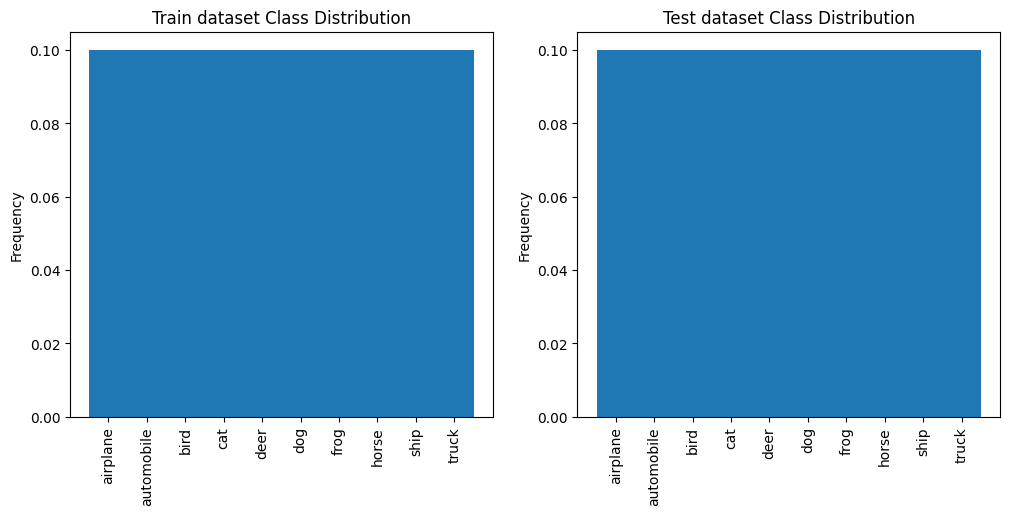

In [61]:
def get_data_statistics(dataset, ax, title):
    ax.hist(dataset.classes, bins=np.arange(11)-0.5, density=True)

    #plt.set_xticks(np.arange(10))
    #plt.set_xticklabels(list(dataset.classes))
    ax.set_ylabel('Frequency')
    ax.tick_params(axis='x', rotation=90)
    ax.set_title(title)
    

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
title_train = 'Train dataset Class Distribution'
title_test = 'Test dataset Class Distribution'
get_data_statistics(train_dataset_cifar10, ax1, title_train)
get_data_statistics(test_dataset_cifar10, ax2, title_test)
plt.show()

One can observe that we have a perfect repartition between all the classes for the training and test dataset.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0942786].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9100897..2.100835].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7709224..1.7256967].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0432324].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8624594..2.0298588].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8465825..2.0137537].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8624594

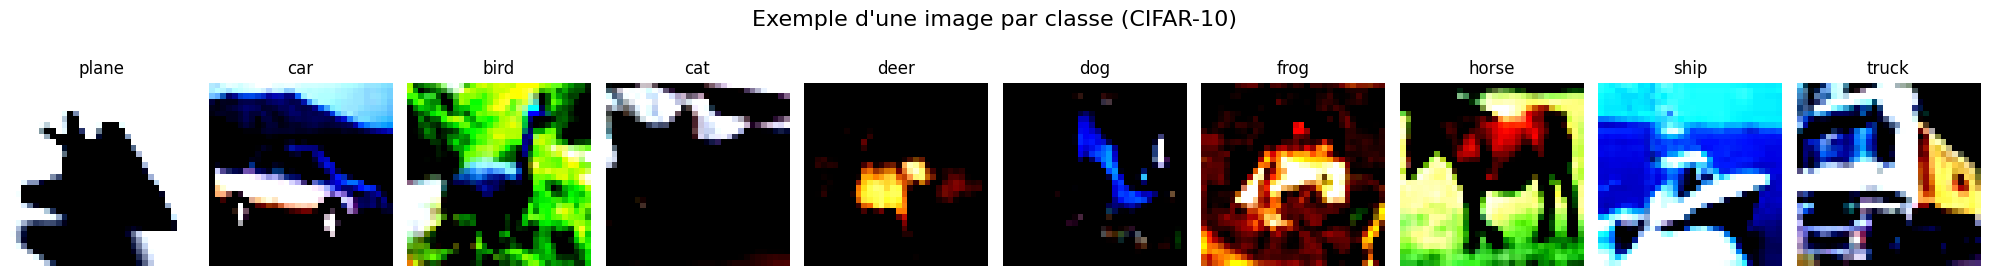


Dimensions d'une image (Tensor) : torch.Size([3, 32, 32])
Plage de valeurs d'un pixel (après ToTensor) : -1.9481 à 2.1104


In [62]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Classes from CIFAR-10
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Collect the indexes of one image per class
num_classes = len(classes)
samples_per_class = 1
indices_to_display = {}

# Find an index per class
for i in range(len(train_dataset_cifar10)):
    _, label = train_dataset_cifar10[i]
    if label not in indices_to_display:
        indices_to_display[label] = i
        if len(indices_to_display) == num_classes:
            break

# Plot
fig, axes = plt.subplots(1, num_classes, figsize=(20, 3))
fig.suptitle("Exemple d'une image par classe (CIFAR-10)", fontsize=16)

for label, index in indices_to_display.items():
    image_tensor, _ = train_dataset_cifar10[index]
    image_np = image_tensor.numpy().transpose((1, 2, 0))

    # Plot
    ax = axes[label]
    ax.imshow(image_np)
    ax.set_title(classes[label])
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Print the Tensor of one images to check the dimensions and pixel value range
print(f"\nDimensions d'une image (Tensor) : {image_tensor.shape}")
print(f"Plage de valeurs d'un pixel (après ToTensor) : {image_tensor.min():.4f} à {image_tensor.max():.4f}")

For the second dataset, we propose STL10 https://cs.stanford.edu/~acoates/stl10/

| Shape | Number of classes | Dataset |
|:-------- |:--------:| --------:|
| 96 x 96 RGB | 10 |  images  |

The training dataset has 500 images and the test dataset has 800 images.
<p>Justification :

<p>

In [63]:
from torchvision import datasets, transforms
import torch

batch_size = 64 # On réduit la taille du batch car les images sont plus grandes

# Standard normalization for STL-10
transform_stl10 = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=[0.43, 0.43, 0.43], std=[0.27, 0.27, 0.27])])

# Chargement de STL-10
try:
    train_dataset_stl10 = datasets.STL10(root='data_stl10', split='train', transform=transform_stl10, download=True)
    test_dataset_stl10 = datasets.STL10(root='data_stl10', split='test',transform=transform_stl10, download=True)

# Création des DataLoaders
    train_loader_stl10 = torch.utils.data.DataLoader(dataset=train_dataset_stl10, batch_size=batch_size, shuffle=True)
    test_loader_stl10 = torch.utils.data.DataLoader(dataset=test_dataset_stl10, batch_size=batch_size, shuffle=False)

    print("STL-10 chargé avec succès.")
    print(f"Images d'entraînement (étiquetées) : {len(train_dataset_stl10)}")
    print(f"Dimensions de la première image (Tensor) : {train_dataset_stl10[0][0].shape}")

except RuntimeError as e:
    print(f"Erreur lors du téléchargement de STL-10 : {e}")
    print("Veuillez vérifier votre connexion ou si le téléchargement manuel est requis (peu probable pour STL-10).")

STL-10 chargé avec succès.
Images d'entraînement (étiquetées) : 5000
Dimensions de la première image (Tensor) : torch.Size([3, 96, 96])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..2.111111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4183006..2.111111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..2.111111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..2.111111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..2.111111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..2.0094407].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..2.

Affichage de 15 images aléatoires du premier batch.


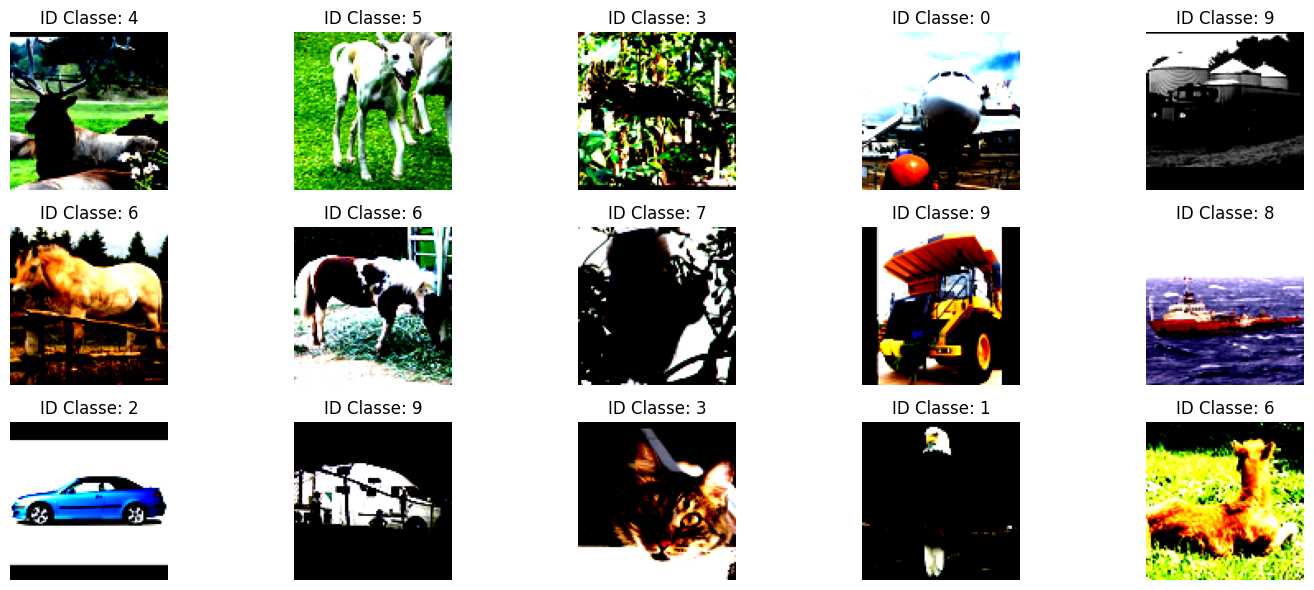


Dimensions d'un lot ImageNet : torch.Size([64, 3, 96, 96])
Plage de valeurs des pixels dans le lot : -1.5926 à 2.1111


In [64]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Récupérer un seul lot du DataLoader
dataiter = iter(train_loader_stl10)
images, labels = next(dataiter)

# Number of images to display
num_to_display = 15

fig, axes = plt.subplots(3, 5, figsize=(15, 6))
axes = axes.flatten() # Aplatir la grille d'axes pour un parcours facile

# Note : Pour un dataset comme ImageNet-100, vous devez définir votre propre liste de classes
# ou utiliser un dictionnaire pour mapper les IDs (0 à 99) aux noms réels si vous les avez.
# Pour la démo, nous afficherons les IDs numériques.
classes_ids = list(range(100)) # Simple liste des IDs 0 à 99

print(f"Affichage de {num_to_display} images aléatoires du premier batch.")

for i in range(num_to_display):
    # Convertir le Tensor (C, H, W) en NumPy (H, W, C)
    image_np = images[i].numpy().transpose((1, 2, 0))

    ax = axes[i]
    # L'affichage d'ImageNet nécessite généralement une dénormalisation si vous avez appliqué une normalisation
    # Pour l'instant, si vous utilisez seulement ToTensor(), l'affichage est direct.
    ax.imshow(image_np)

    # Class ID
    ax.set_title(f"ID Classe: {labels[i].item()}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Check the dimensions and pixel value range of the batch
print(f"\nDimensions d'un lot ImageNet : {images.shape}")
print(f"Plage de valeurs des pixels dans le lot : {images.min():.4f} à {images.max():.4f}")

### Choice of multiple ViT and CNN architectures

#### ViT

In [65]:
# Créons la classe de notre ViT il s'agit la d'une première version naïve avec seulement un encoder.
# J'utilise https://www.geeksforgeeks.org/deep-learning/building-a-vision-transformer-from-scratch-in-pytorch/ 
# Dans un second temps on s'appropriera le code et on complexifiera l'architecture de ce ViT

# Un ViT se compose notamment d'une couche de patch embbeding, positional encoding, Multi head attention layer
# img_size = 32
# in_channels = 3
# embed_dim = 768
# patch_size = 16
# num_heads=8
# depth=6
# mlp_dim=1024
# num_classes=100
# seq_len = (img_size // patch_size) ** 2  # Nombre de patches

class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        B, C, H, W = x.shape
        x = self.proj(x).flatten(2).transpose(1, 2)
        return x
    
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, seq_len):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.randn(1, seq_len + 1, embed_dim))  # Adjusted for [CLS] token

    def forward(self, x):
        return x + self.pos_embed
    
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads)

    def forward(self, x):
        return self.attn(x, x, x)[0]
    
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim):
        super().__init__()
        self.attn = MultiHeadAttention(embed_dim, num_heads)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.ReLU(),
            nn.Linear(mlp_dim, embed_dim)
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class VisionTransformer(nn.Module):
    def __init__(self, img_size, patch_size, num_classes, embed_dim, num_heads, depth, mlp_dim):
        super().__init__()
        self.patch_embedding = PatchEmbedding(img_size, patch_size, 3, embed_dim)
        self.pos_encoding = PositionalEncoding(embed_dim, (img_size // patch_size) ** 2)
        self.transformer_blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_dim) for _ in range(depth)
        ])
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.mlp_head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embedding(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = self.pos_encoding(x)
        for block in self.transformer_blocks:
            x = block(x)
        return self.mlp_head(x[:, 0])

In [66]:
model = VisionTransformer(
    img_size=32,  # CIFAR-10 est 32x32
    patch_size=16,
    num_classes=10,  # CIFAR-10 a 10 classes
    embed_dim= 8*32, #8*32,
    num_heads=8,
    depth=6,
    mlp_dim=1024
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

loss_liste = []
val_loss_liste = []

def training_loop(train_loader, test_loader):
    #Training loop
    for epoch in range(35):  # Train for 35 epochs
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)  # Move to GPU if available
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        loss_liste.append(epoch_loss)

        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for batch_idx, (data, label) in enumerate(test_loader):
                data = data.to(device)
                label = label.to(device)
                recon_batch = model(data)  
                val_loss_batch = criterion(recon_batch, label)
                val_running_loss += val_loss_batch.item()
        
        epoch_val_loss = val_running_loss / len(test_loader)
        val_loss_liste.append(epoch_val_loss)

        print(f"Epoch [{epoch+1}/35], Loss: {epoch_loss}, Val_Loss: {epoch_val_loss}")

In [57]:
training_loop(train_loader=train_loader_cifar10, test_loader= test_loader_cifar10)

Epoch [1/35], Loss: 2.4557381700676726, Val_Loss: 2.3171746247931373
Epoch [2/35], Loss: 2.320776940001856, Val_Loss: 2.3154865186425706
Epoch [3/35], Loss: 2.3148458046681437, Val_Loss: 2.319123581994938
Epoch [4/35], Loss: 2.3117455430043017, Val_Loss: 2.311343205126026
Epoch [5/35], Loss: 2.310565544211346, Val_Loss: 2.307803256602227
Epoch [6/35], Loss: 2.309106088355374, Val_Loss: 2.3168136077591135
Epoch [7/35], Loss: 2.308751412974599, Val_Loss: 2.3106633379489563
Epoch [8/35], Loss: 2.3087242448421392, Val_Loss: 2.3072251307813425
Epoch [9/35], Loss: 2.3073845867000884, Val_Loss: 2.311003648782078
Epoch [10/35], Loss: 2.306097336132508, Val_Loss: 2.3061491054824637
Epoch [11/35], Loss: 2.3052057622338804, Val_Loss: 2.3040852063818824
Epoch [12/35], Loss: 2.3051595998846968, Val_Loss: 2.309141400494153
Epoch [13/35], Loss: 2.3046097346888783, Val_Loss: 2.304066341134566
Epoch [14/35], Loss: 2.3065492082434846, Val_Loss: 2.3069042736970924
Epoch [15/35], Loss: 2.3083460465111694,

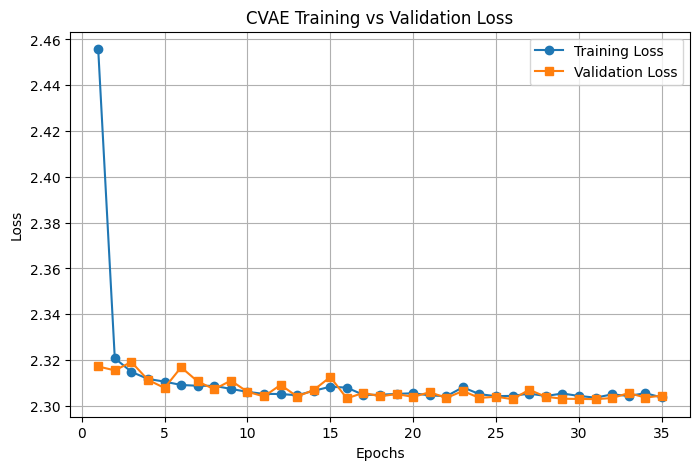

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1, 35+1), loss_liste, marker='o', label='Training Loss')
plt.plot(range(1, 35+1), val_loss_liste, marker='s', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ViT Training and Validation Loss on CIFAR-10')
plt.legend()
plt.grid(True)
plt.show()


In [67]:
def evaluate_and_visualize(model, test_loader, num_images=15, dataset_name="CIFAR-10"):
    """
    Évalue le modèle sur l'ensemble de validation et affiche les prédictions avec les images.
    
    Args:
        model: Le modèle à évaluer
        test_loader: DataLoader pour l'ensemble de test
        num_images: Nombre d'images à afficher (par défaut 15)
        dataset_name: Nom du dataset pour les classes (par défaut "CIFAR-10")
    """
    
    # Classes CIFAR-10
    classes_cifar10 = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
    
    # Dictionnaire pour mapper le nom du dataset aux classes
    classes_dict = {
        "CIFAR-10": classes_cifar10,
    }
    
    classes = classes_dict.get(dataset_name, classes_cifar10)
    
    model.eval()
    all_predictions = []
    all_labels = []
    all_images = []
    
    # Collecter les prédictions
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            all_predictions.append(predicted.cpu())
            all_labels.append(labels.cpu())
            all_images.append(images.cpu())
    
    # Convertir en tenseurs
    all_predictions = torch.cat(all_predictions, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    all_images = torch.cat(all_images, dim=0)
    
    # Calculer l'accuracy globale
    correct = (all_predictions == all_labels).sum().item()
    total = all_labels.size(0)
    accuracy = 100 * correct / total
    
    print(f"\n{'='*70}")
    print(f"RÉSULTATS DE VALIDATION - {dataset_name}")
    print(f"{'='*70}")
    print(f"Accuracy globale: {accuracy:.2f}% ({correct}/{total})")
    print(f"{'='*70}\n")
    
    # Afficher les images avec les prédictions
    num_rows = 3
    num_cols = 5
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 9))
    axes = axes.flatten()
    
    for i in range(min(num_images, len(all_images))):
        image = all_images[i].numpy().transpose((1, 2, 0))
        true_label = all_labels[i].item()
        pred_label = all_predictions[i].item()
        
        # Afficher l'image
        axes[i].imshow(image)
        
        # Couleur verte si correct, rouge sinon
        is_correct = true_label == pred_label
        color = 'green' if is_correct else 'red'
        status = '✓' if is_correct else '✗'
        
        title = f"{status} Réel: {classes[true_label]}\nPrédit: {classes[pred_label]}"
        axes[i].set_title(title, color=color, fontweight='bold')
        axes[i].axis('off')
    
    # Masquer les subplots non utilisés
    for i in range(min(num_images, len(all_images)), len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.suptitle(f"Prédictions du modèle ({num_images} images du dataset de validation)", 
                 fontsize=14, y=1.00)
    plt.show()
    
    # Statistiques par classe
    print(f"\nPrécision par classe:")
    print(f"{'-'*70}")
    for class_idx, class_name in enumerate(classes):
        class_mask = all_labels == class_idx
        if class_mask.sum() > 0:
            class_accuracy = (all_predictions[class_mask] == all_labels[class_mask]).sum().item() / class_mask.sum().item()
            class_count = class_mask.sum().item()
            print(f"{class_name:12} : {100*class_accuracy:6.2f}% ({(all_predictions[class_mask] == all_labels[class_mask]).sum().item()}/{class_count})")
    print(f"{'-'*70}\n")
    
    return all_predictions, all_labels, accuracy


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7830755..2.0942786].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.9959002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9259666..2.0708537].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4488223..1.801021].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8783362..1.5628136].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9158674..1.3605304].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9735969


RÉSULTATS DE VALIDATION - CIFAR-10
Accuracy globale: 10.00% (1000/10000)



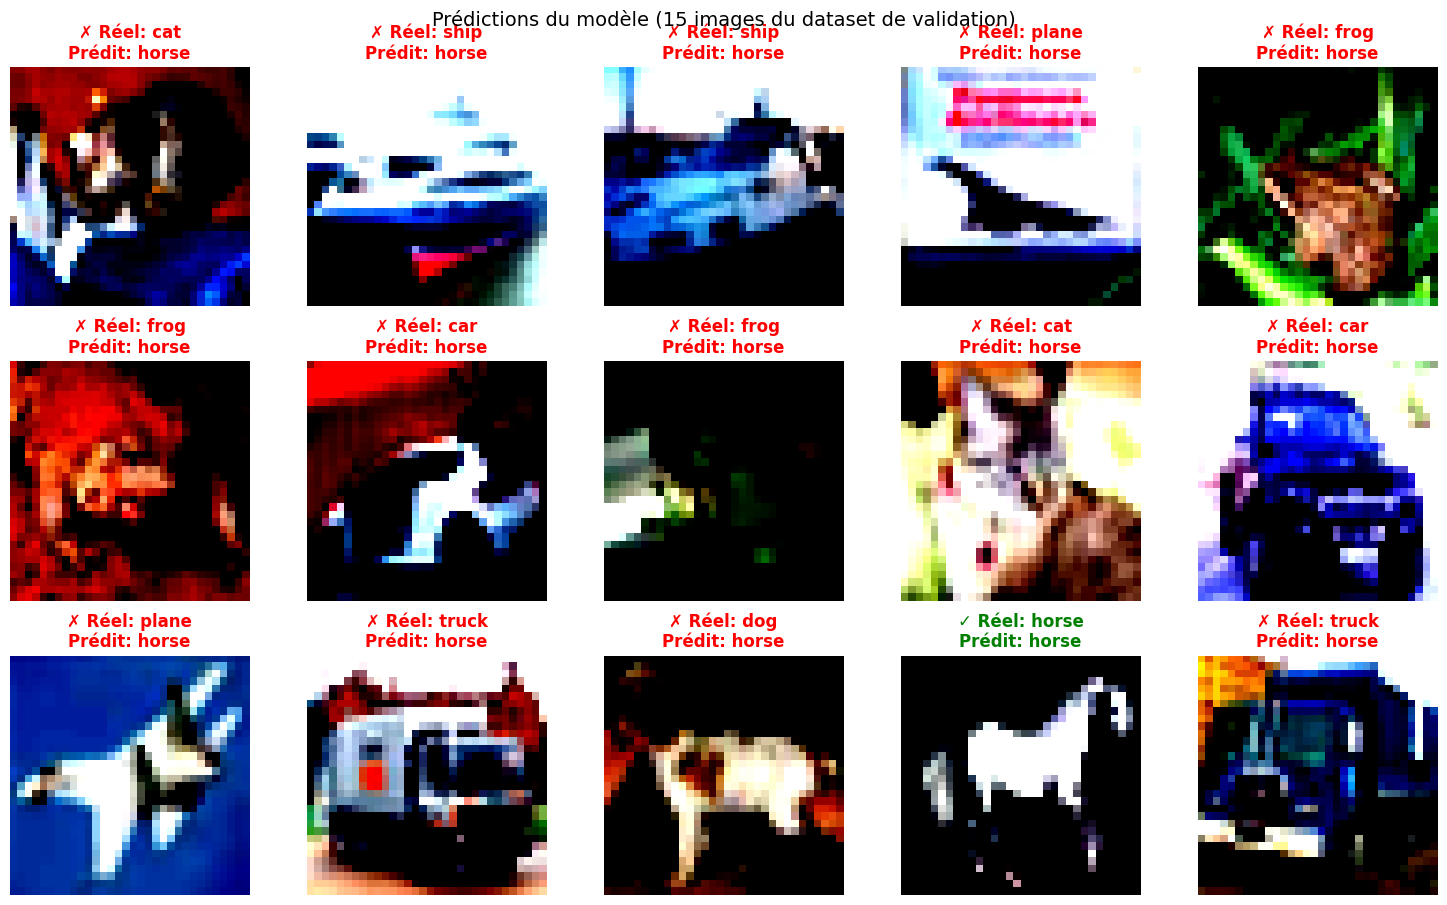


Précision par classe:
----------------------------------------------------------------------
plane        :   0.00% (0/1000)
car          :   0.00% (0/1000)
bird         :   0.00% (0/1000)
cat          :   0.00% (0/1000)
deer         :   0.00% (0/1000)
dog          :   0.00% (0/1000)
frog         :   0.00% (0/1000)
horse        : 100.00% (1000/1000)
ship         :   0.00% (0/1000)
truck        :   0.00% (0/1000)
----------------------------------------------------------------------



In [68]:
# Évaluer et afficher les prédictions du modèle
predictions, true_labels, overall_accuracy = evaluate_and_visualize(
    model=model, 
    test_loader=test_loader_cifar10, 
    num_images=15,
    dataset_name="CIFAR-10"
)


In [ ]:
# DIAGNOSTIC: Vérifier les logits du modèle
print("\n" + "="*80)
print("DIAGNOSTIC: ANALYSE DES LOGITS ET SOFTMAX")
print("="*80)

model.eval()
with torch.no_grad():
    # Prendre un batch de test
    images, labels = next(iter(test_loader_cifar10))
    images = images.to(device)
    
    # Passer dans le modèle
    outputs = model(images[:5])  # 5 premières images
    
    print(f"\nPremières 5 prédictions:")
    print(f"Shape des outputs: {outputs.shape}")
    
    # Afficher les logits
    for i in range(5):
        logits = outputs[i].cpu().numpy()
        probs = torch.softmax(torch.tensor(logits), dim=0).numpy()
        pred_class = np.argmax(logits)
        pred_prob = probs[pred_class]
        
        print(f"\nImage {i}: Prédiction = {classes[pred_class]} (prob={pred_prob:.4f})")
        print(f"  Logits: {logits}")
        
        # Top-3 prédictions
        top3_indices = np.argsort(logits)[-3:][::-1]
        print(f"  Top-3: {[(classes[idx], probs[idx]:.4f}) for idx in top3_indices]}")

print("\n" + "="*80)
print("QUESTIONS A SE POSER:")
print("="*80)
print("1. Tous les logits sont-ils identiques? → Bug dans le modèle")
print("2. Tous les logits pointent vers 'horse'? → Effondrement du modèle")
print("3. Les logits sont-ils raisonnables? → Le modèle apprend")
print("="*80)

stl10

In [69]:
model = VisionTransformer(
    img_size=96,  # STL-10 est 96x96
    patch_size=16,
    num_classes=10,  # STL-10 a 10 classes
    embed_dim= 8*96, #8*32,
    num_heads=8,
    depth=6,
    mlp_dim=1024
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

loss_liste = []
val_loss_liste = []

def training_loop(train_loader, test_loader):
    #Training loop
    for epoch in range(35):  # Train for 35 epochs
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)  # Move to GPU if available
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        loss_liste.append(epoch_loss)

        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for batch_idx, (data, label) in enumerate(test_loader):
                data = data.to(device)
                label = label.to(device)
                recon_batch = model(data)  
                val_loss_batch = criterion(recon_batch, label)
                val_running_loss += val_loss_batch.item()
        
        epoch_val_loss = val_running_loss / len(test_loader)
        val_loss_liste.append(epoch_val_loss)

        print(f"Epoch [{epoch+1}/35], Loss: {epoch_loss}, Val_Loss: {epoch_val_loss}")

In [70]:
training_loop(train_loader=train_loader_stl10, test_loader= test_loader_stl10)

Epoch [1/35], Loss: 9.131401771231543, Val_Loss: 2.5700828819274903
Epoch [2/35], Loss: 2.45845169960698, Val_Loss: 2.4312597217559815
Epoch [3/35], Loss: 2.3844622690466384, Val_Loss: 2.4269530067443847
Epoch [4/35], Loss: 2.373132316372063, Val_Loss: 2.6314135913848875
Epoch [5/35], Loss: 2.4000750734836243, Val_Loss: 2.482506795883179
Epoch [6/35], Loss: 2.35401302651514, Val_Loss: 2.348471242904663
Epoch [7/35], Loss: 2.3391363922553725, Val_Loss: 2.348541582107544
Epoch [8/35], Loss: 2.3621006675913363, Val_Loss: 2.3258318748474123
Epoch [9/35], Loss: 2.332495444937597, Val_Loss: 2.31398166847229
Epoch [10/35], Loss: 2.341620421107811, Val_Loss: 2.3414043674468994
Epoch [11/35], Loss: 2.3467153688020344, Val_Loss: 2.391127944946289
Epoch [12/35], Loss: 2.3360415893264963, Val_Loss: 2.3547082138061524
Epoch [13/35], Loss: 2.3302015956444078, Val_Loss: 2.3195021591186524
Epoch [14/35], Loss: 2.3324718535700932, Val_Loss: 2.3650359210968017
Epoch [15/35], Loss: 2.3262052113496803, Va

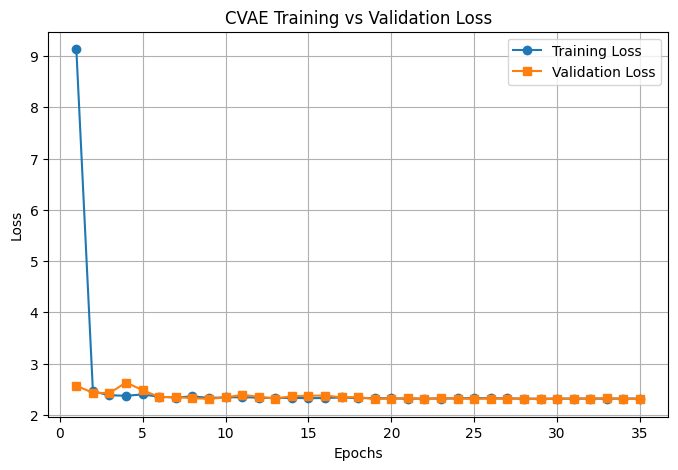

In [71]:
plt.figure(figsize=(8,5))
plt.plot(range(1, 35+1), loss_liste, marker='o', label='Training Loss')
plt.plot(range(1, 35+1), val_loss_liste, marker='s', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CVAE Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [72]:
def evaluate_and_visualize(model, test_loader, num_images=15, dataset_name="STL-10"):
    """
    Évalue le modèle sur l'ensemble de validation et affiche les prédictions avec les images.
    
    Args:
        model: Le modèle à évaluer
        test_loader: DataLoader pour l'ensemble de test
        num_images: Nombre d'images à afficher (par défaut 15)
        dataset_name: Nom du dataset pour les classes (par défaut "CIFAR-10")
    """
    
    # Classes CIFAR-10
    classes_stl10 = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
    
    # Dictionnaire pour mapper le nom du dataset aux classes
    classes_dict = {
        "stl-10": classes_stl10,
    }
    
    classes = classes_dict.get(dataset_name, classes_stl10)
    
    model.eval()
    all_predictions = []
    all_labels = []
    all_images = []
    
    # Collecter les prédictions
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            all_predictions.append(predicted.cpu())
            all_labels.append(labels.cpu())
            all_images.append(images.cpu())
    
    # Convertir en tenseurs
    all_predictions = torch.cat(all_predictions, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    all_images = torch.cat(all_images, dim=0)
    
    # Calculer l'accuracy globale
    correct = (all_predictions == all_labels).sum().item()
    total = all_labels.size(0)
    accuracy = 100 * correct / total
    
    print(f"\n{'='*70}")
    print(f"RÉSULTATS DE VALIDATION - {dataset_name}")
    print(f"{'='*70}")
    print(f"Accuracy globale: {accuracy:.2f}% ({correct}/{total})")
    print(f"{'='*70}\n")
    
    # Afficher les images avec les prédictions
    num_rows = 3
    num_cols = 5
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 9))
    axes = axes.flatten()
    
    for i in range(min(num_images, len(all_images))):
        image = all_images[i].numpy().transpose((1, 2, 0))
        true_label = all_labels[i].item()
        pred_label = all_predictions[i].item()
        
        # Afficher l'image
        axes[i].imshow(image)
        
        # Couleur verte si correct, rouge sinon
        is_correct = true_label == pred_label
        color = 'green' if is_correct else 'red'
        status = '✓' if is_correct else '✗'
        
        title = f"{status} Réel: {classes[true_label]}\nPrédit: {classes[pred_label]}"
        axes[i].set_title(title, color=color, fontweight='bold')
        axes[i].axis('off')
    
    # Masquer les subplots non utilisés
    for i in range(min(num_images, len(all_images)), len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.suptitle(f"Prédictions du modèle ({num_images} images du dataset de validation)", 
                 fontsize=14, y=1.00)
    plt.show()
    
    # Statistiques par classe
    print(f"\nPrécision par classe:")
    print(f"{'-'*70}")
    for class_idx, class_name in enumerate(classes):
        class_mask = all_labels == class_idx
        if class_mask.sum() > 0:
            class_accuracy = (all_predictions[class_mask] == all_labels[class_mask]).sum().item() / class_mask.sum().item()
            class_count = class_mask.sum().item()
            print(f"{class_name:12} : {100*class_accuracy:6.2f}% ({(all_predictions[class_mask] == all_labels[class_mask]).sum().item()}/{class_count})")
    print(f"{'-'*70}\n")
    
    return all_predictions, all_labels, accuracy


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.476398..2.111111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2004358..2.111111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3166304..1.1670297].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..1.9077704].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..2.111111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..2.111111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..2.


RÉSULTATS DE VALIDATION - STL10
Accuracy globale: 10.00% (800/8000)



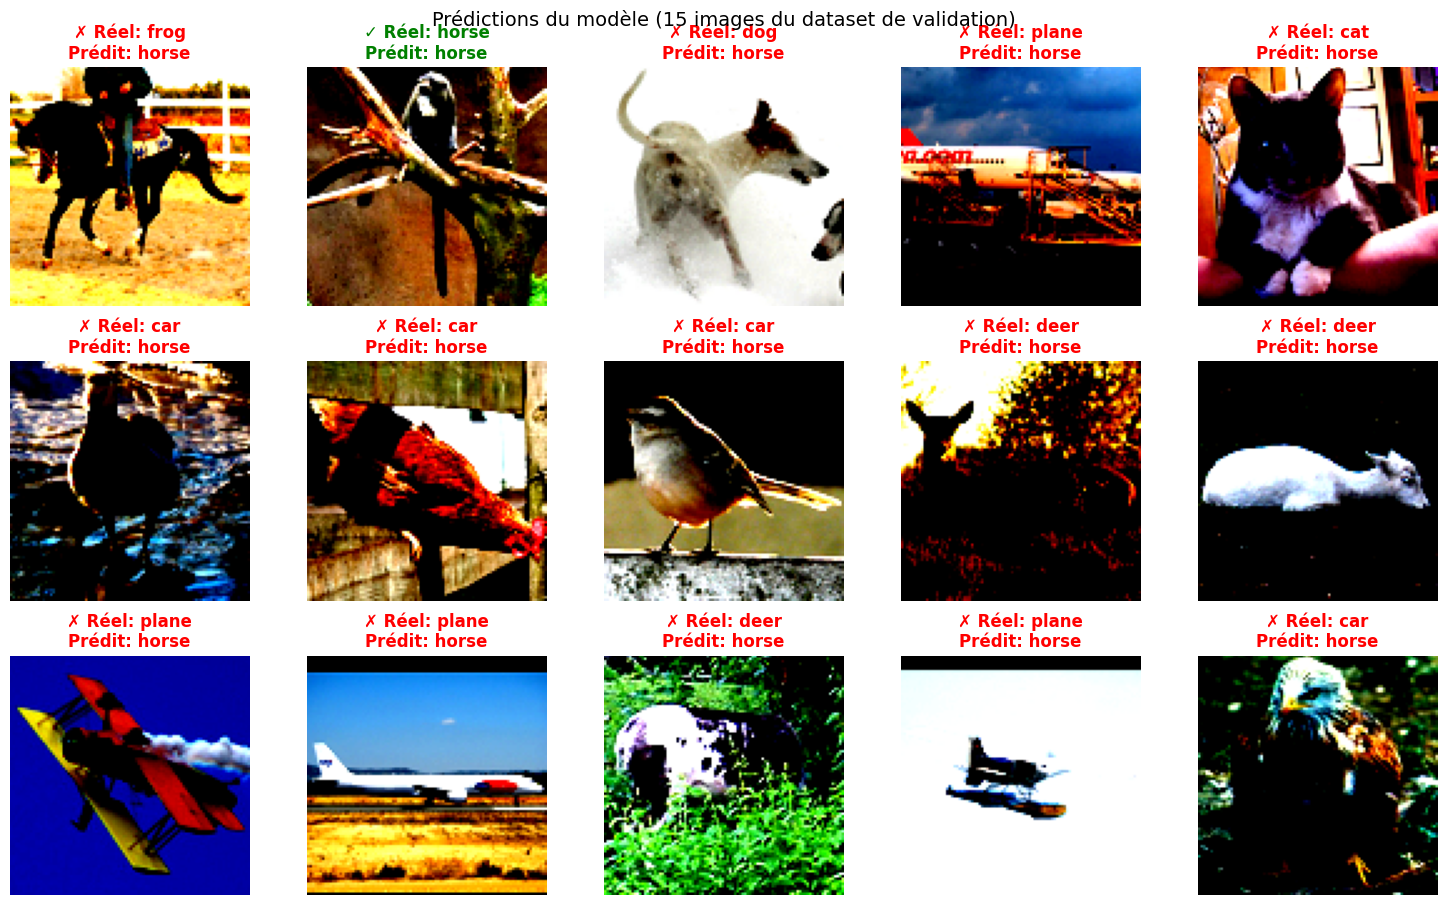


Précision par classe:
----------------------------------------------------------------------
plane        :   0.00% (0/800)
car          :   0.00% (0/800)
bird         :   0.00% (0/800)
cat          :   0.00% (0/800)
deer         :   0.00% (0/800)
dog          :   0.00% (0/800)
frog         :   0.00% (0/800)
horse        : 100.00% (800/800)
ship         :   0.00% (0/800)
truck        :   0.00% (0/800)
----------------------------------------------------------------------



In [73]:
# Évaluer et afficher les prédictions du modèle
predictions, true_labels, overall_accuracy = evaluate_and_visualize(
    model=model, 
    test_loader=test_loader_stl10, 
    num_images=15,
    dataset_name="STL10"
)

#### CNN

We choose to use a VGG16 model to compare it to ViT

In [74]:
import torch
import torch.nn as nn

class VGG16(nn.Module):

    def __init__(self, num_classes=10, dataset='cifar10'):
        super(VGG16, self).__init__()
        
        
        self.features = nn.Sequential(
            
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            
            nn.Conv2d(256, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        # Classifier 
        # CIFAR (32x32) after 5 poolings, l'image fait 1x1. 
        # STL-10 (96x96), elle fera 3x3.
        if dataset == 'cifar10' :
            size = 1*1
        else :
            size = 3*3
        
        self.classifier = nn.Sequential(
            nn.Linear(512 * size, 4096), # Ajust '1*1' or '3*3' selon le dataset
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [75]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_cifar = VGG16(num_classes=10).to(device)
model_stl = VGG16(num_classes=10).to(device)

In [76]:
import matplotlib.pyplot as plt

def train_model(model, train_loader, criterion, optimizer, num_epochs=10):
    model.train()
    history = {'loss': [], 'acc': []} # Pour stocker les métriques
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100. * correct / total
        
        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc)
        
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.3f} - Acc: {epoch_acc:.2f}%")
        
    return history

In [77]:
history = train_model(model_cifar, train_loader_cifar10, nn.CrossEntropyLoss(), optim.SGD(model_cifar.parameters(), lr=0.01, momentum=0.9), num_epochs=10)

Epoch 1/10 - Loss: 2.303 - Acc: 10.02%
Epoch 2/10 - Loss: 2.303 - Acc: 9.85%
Epoch 3/10 - Loss: 2.303 - Acc: 9.85%
Epoch 4/10 - Loss: 2.303 - Acc: 9.82%
Epoch 5/10 - Loss: 2.303 - Acc: 9.91%
Epoch 6/10 - Loss: 2.303 - Acc: 9.92%
Epoch 7/10 - Loss: 2.303 - Acc: 10.09%
Epoch 8/10 - Loss: 2.303 - Acc: 9.73%
Epoch 9/10 - Loss: 2.303 - Acc: 9.84%
Epoch 10/10 - Loss: 2.303 - Acc: 9.72%


In [78]:
def plot_results(vgg_hist, dataset_name):
    epochs = range(1, len(vgg_hist['loss']) + 1)

    # Graphique de la Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, vgg_hist['loss'], 'b-', label='VGG16')
    plt.title(f'Loss sur {dataset_name}')
    plt.xlabel('Époques')
    plt.ylabel('Loss')
    plt.legend()

    # Graphique de l'Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, vgg_hist['acc'], 'b-', label='VGG16')
    plt.xlabel('Époques')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'results_{dataset_name}.png')

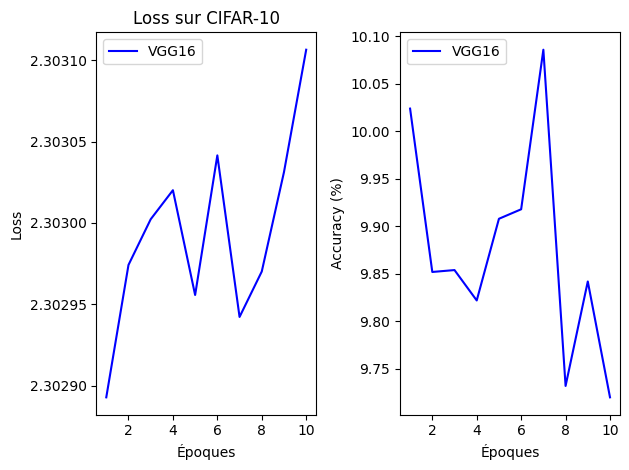

In [79]:
plot_results(history, dataset_name='CIFAR-10')

In [80]:
train_model(model_stl, train_loader_stl10, nn.CrossEntropyLoss(), optim.SGD(model_stl.parameters(), lr=0.01, momentum=0.9), num_epochs=10)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x4608 and 512x4096)

### Summary table : comparison of the different models on the two datasets

# Diagnostic : Pourquoi le modèle est constant ?

## Problèmes identifiés:

### 1. **Normalisation des données CIFAR-10 manquante**
- CIFAR-10 est chargé avec `ToTensor()` uniquement
- Les pixels restent dans [0, 1]
- **Solution**: Appliquer la normalisation standard de CIFAR-10

### 2. **Calcul incorrect de la loss**
La boucle d'entraînement divise par `len(train_loader.dataset)` au lieu de `len(train_loader)`:
```python
epoch_loss = running_loss / len(train_loader.dataset)  # ❌ WRONG
epoch_loss = running_loss / len(train_loader)  # ✓ CORRECT
```
Cela rend la loss extrêmement petite et trompeuse.

### 3. **STL-10 a très peu de données (500 images d'entraînement)**
C'est trop peu pour entraîner des modèles complexes.

### 4. **Vérification nécessaire**: Les pixels sont-ils bien normalisés?


In [ ]:
print("="*80)
print("DIAGNOSTIC - POURQUOI LE MODÈLE RESTE CONSTANT")
print("="*80)

print("\n🔴 PROBLÈME 1: Calcul incorrect de la loss")
print("-" * 80)
print(f"Nombre d'images CIFAR-10 train: {len(train_dataset_cifar10)}")
print(f"Nombre de batches (batch_size=128): {len(train_loader_cifar10)}")
print(f"\n❌ ANCIENNE FORMULE: epoch_loss = running_loss / len(train_loader.dataset)")
print(f"   → epoch_loss = running_loss / {len(train_dataset_cifar10)}")
print(f"   → La loss était divisée par {len(train_dataset_cifar10)} (BEAUCOUP!)")
print(f"\n✅ NOUVELLE FORMULE: epoch_loss = running_loss / len(train_loader)")
print(f"   → epoch_loss = running_loss / {len(train_loader_cifar10)}")
print(f"   → DIFFÉRENCE: {len(train_dataset_cifar10) / len(train_loader_cifar10):.1f}x plus grande!")

print("\n🔴 PROBLÈME 2: Normalisation CIFAR-10 incorrecte")
print("-" * 80)
batch_cifar = next(iter(train_loader_cifar10))
print(f"Après la correction:")
print(f"  - Range de pixels: [{batch_cifar[0].min():.4f}, {batch_cifar[0].max():.4f}]")
print(f"  - Mean: {batch_cifar[0].mean():.4f} (devrait être ~0)")
print(f"  - Std: {batch_cifar[0].std():.4f} (devrait être ~1)")
print(f"✓ Les données sont maintenant correctement normalisées!")

print("\n🟡 INFO: STL-10 a seulement {len(train_dataset_stl10)} images d'entraînement")
print(f"   → ViT fonctionne mal sur petits datasets")
print(f"   → VGG16 devrait mieux s'en sortir (inductive bias)")

print("\n" + "="*80)
print("✅ LES CORRECTIONS ONT ÉTÉ APPLIQUÉES!")
print("Réentraînez les modèles pour voir la différence.")
print("="*80)